# Lab 14 — MobileNetV2 Baseline (Clean, Colab-Ready)

Deepfake Detection for Video KYC — MobileNetV2 baseline training and evaluation on the
**complete** `aishwarya99990/faceforensics-kyc-processed` Kaggle dataset.

This notebook is self-contained: it can be run top-to-bottom on a fresh Colab runtime
(**Runtime → Restart session** then **Run all**) with a T4 GPU, with no dependency on
Google Drive and no reliance on variables left over from previous runs.

Expected complete dataset sizes:

| Split | real | fake | total |
|---|---|---|---|
| train | 4965 | 24744 | **29709** |
| val   | 1082 | 5475  | **6557**  |
| test  | 1059 | 5377  | **6436**  |


## 1. Environment setup

In [2]:
!pip install -q kaggle scikit-learn

In [3]:
import os
import sys
import json
import shutil
from pathlib import Path
from getpass import getpass

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)


Running in Colab: True


In [4]:
# Clone (or reuse) the project repository so we have access to
# src.dataset.dataloader.FaceDataset and the rest of the project code.
REPO_URL = "https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git"
REPO_NAME = "Deepfake-Detection-KYC"

if IN_COLAB:
    os.chdir("/content")
    if not Path(REPO_NAME).exists():
        exit_code = os.system(f"git clone {REPO_URL}")
        if exit_code != 0:
            raise RuntimeError("git clone failed. Check REPO_URL / network access.")
    os.chdir(REPO_NAME)
else:
    print("Not running in Colab - assuming the notebook already sits inside the repo.")

print("Working directory:", Path.cwd())


Working directory: /content/Deepfake-Detection-KYC


In [5]:
def find_project_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing both
    `src/` and `data/` is found. Falls back to `start` if not found."""
    for directory in [start] + list(start.parents):
        if (directory / "src").is_dir() and (directory / "data").is_dir():
            return directory
    return start


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

assert (PROJECT_ROOT / "src" / "dataset" / "dataloader.py").exists(), (
    "Could not locate src/dataset/dataloader.py under the detected project root. "
    "Check that the repository cloned correctly."
)


Project root: /content/Deepfake-Detection-KYC


In [6]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

import matplotlib.pyplot as plt

from src.dataset.dataloader import FaceDataset

print("PyTorch version:  ", torch.__version__)
print("Torchvision version:", torchvision.__version__)

if torch.cuda.is_available():
    print("CUDA available: Yes")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA available: No (Runtime > Change runtime type > T4 GPU is recommended)")


PyTorch version:   2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: Yes
GPU: Tesla T4


## 2. Kaggle authentication

Uses the existing Colab secret **`KAGGLE_API_TOKEN`** — the same token-based
mechanism that already worked in the previous notebook (`Kaggle token loaded: True`).
No separate `KAGGLE_USERNAME`/`KAGGLE_KEY` secrets are required when
`KAGGLE_API_TOKEN` is available. An interactive prompt is kept only as a fallback,
in case the secret isn't present (e.g. a different Colab account/notebook).

In [8]:
def load_kaggle_credentials():
    """Authenticate with Kaggle using the existing KAGGLE_API_TOKEN Colab
    secret (the mechanism that already worked previously). Falls back to an
    interactive prompt only if that secret isn't available."""

    token = None
    username = None

    if IN_COLAB:
        try:
            from google.colab import userdata
            token = userdata.get("KAGGLE_API_TOKEN")
        except Exception:
            token = None

    if token:
        # KAGGLE_KEY is what the kaggle CLI/library actually reads; KAGGLE_API_TOKEN
        # is kept too since that's the name the existing secret/notebook used.
        os.environ["KAGGLE_API_TOKEN"] = token
        os.environ["KAGGLE_KEY"] = token

        if IN_COLAB:
            try:
                username = userdata.get("KAGGLE_USERNAME")
            except Exception:
                username = None
        if username:
            os.environ["KAGGLE_USERNAME"] = username

        print("Kaggle token loaded:", bool(token))
    else:
        print("KAGGLE_API_TOKEN secret not found.")
        print("Falling back to interactive input.")
        username = input("Kaggle username: ").strip()
        key = getpass("Kaggle API key: ").strip()

        kaggle_dir = Path.home() / ".kaggle"
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        kaggle_json_path = kaggle_dir / "kaggle.json"
        kaggle_json_path.write_text(json.dumps({"username": username, "key": key}))
        kaggle_json_path.chmod(0o600)

        os.environ["KAGGLE_USERNAME"] = username
        os.environ["KAGGLE_KEY"] = key

        print("Kaggle credentials configured:", bool(username and key))


load_kaggle_credentials()


Kaggle token loaded: True


## 3. Dataset download

Downloads directly into **one single canonical location** —
`PROJECT_ROOT/data/kaggle_processed` — so we never end up with duplicate copies of
this large dataset (e.g. a separate `/content/kaggle_full_dataset` plus a copy under
the project). If the dataset already exists with the expected structure, the download
is skipped.

In [9]:
KAGGLE_DATASET_SLUG = "aishwarya99990/faceforensics-kyc-processed"

# Single canonical dataset location - do not duplicate this elsewhere.
DATASET_ROOT = PROJECT_ROOT / "data" / "kaggle_processed"
DATASET_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_COUNTS = {
    "train": {"real": 4965, "fake": 24744},
    "val":   {"real": 1082, "fake": 5475},
    "test":  {"real": 1059, "fake": 5377},
}


def dataset_looks_complete(root: Path) -> bool:
    for split, labels in EXPECTED_COUNTS.items():
        for label in labels:
            folder = root / split / label
            if not folder.exists():
                return False
    return True


if dataset_looks_complete(DATASET_ROOT):
    print("Dataset already present at:", DATASET_ROOT)
    print("Skipping download. (Delete this folder to force a re-download.)")
else:
    print("Downloading complete Kaggle dataset to:", DATASET_ROOT)
    exit_code = os.system(
        f'kaggle datasets download -d {KAGGLE_DATASET_SLUG} -p "{DATASET_ROOT}" --unzip'
    )
    if exit_code != 0:
        raise RuntimeError(
            "kaggle datasets download failed. Check your Kaggle credentials "
            "(Section 2) and that you have accepted the dataset's terms on Kaggle."
        )
    print("Download complete.")


Download complete.


## 4. Dataset structure verification

In [10]:
print("DATASET_ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split
    print(f"\n--- {split} ---")
    print("Exists:", split_dir.exists())
    if not split_dir.exists():
        continue
    for label in ["real", "fake"]:
        folder = split_dir / label
        count = len(list(folder.glob("*"))) if folder.exists() else 0
        print(f"  {label}: {count} files (exists={folder.exists()})")


DATASET_ROOT: /content/Deepfake-Detection-KYC/data/kaggle_processed
Exists: True

--- train ---
Exists: True
  real: 4965 files (exists=True)
  fake: 24744 files (exists=True)

--- val ---
Exists: True
  real: 1082 files (exists=True)
  fake: 5475 files (exists=True)

--- test ---
Exists: True
  real: 1059 files (exists=True)
  fake: 5377 files (exists=True)


## 5. Corrupted / unreadable image detection & cleanup

Generic validation routine — checks **every** image in every split/class folder,
not just the one zero-byte file (`train/fake/Face2Face_419_824_frame10_face0.jpg`)
seen previously. Any unreadable or zero-byte file is moved into a `quarantine`
folder alongside the dataset (never silently deleted, so nothing is lost
permanently) and excluded from training/eval.

This runs **before** any `FaceDataset`/`DataLoader` is constructed, so a bad file
can never crash a DataLoader worker mid-training.

In [11]:
from PIL import Image

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
QUARANTINE_ROOT = DATASET_ROOT.parent / "kaggle_processed_quarantine"


def find_bad_images(root: Path):
    """Return a list of (path, reason) for every zero-byte or unreadable image
    under root/{split}/{real,fake}."""
    bad = []
    for split in ["train", "val", "test"]:
        for label in ["real", "fake"]:
            folder = root / split / label
            if not folder.exists():
                continue
            for path in folder.iterdir():
                if not path.is_file() or path.suffix.lower() not in IMAGE_SUFFIXES:
                    continue
                try:
                    if path.stat().st_size == 0:
                        bad.append((path, "zero-byte file"))
                        continue
                    with Image.open(path) as img:
                        img.verify()
                    # verify() only checks structure; re-open and force a full
                    # decode to catch truncated/corrupt image data too.
                    with Image.open(path) as img:
                        img.convert("RGB").load()
                except Exception as e:
                    bad.append((path, repr(e)))
    return bad


def quarantine_bad_images(bad_files):
    """Move bad files out of the dataset into QUARANTINE_ROOT, preserving
    their split/class sub-path, so training data stays clean without
    silently deleting anything."""
    for path, reason in bad_files:
        rel = path.relative_to(DATASET_ROOT)
        dest = QUARANTINE_ROOT / rel
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(path), str(dest))
    print(f"Quarantined {len(bad_files)} file(s) to: {QUARANTINE_ROOT}")


print("Scanning for corrupted/unreadable images (this can take a few minutes)...")
bad_files = find_bad_images(DATASET_ROOT)
print(f"Found {len(bad_files)} corrupted/unreadable/zero-byte image(s).")

for path, reason in bad_files[:50]:
    print(" -", path, "|", reason)
if len(bad_files) > 50:
    print(f"  ... and {len(bad_files) - 50} more")

if bad_files:
    quarantine_bad_images(bad_files)


Scanning for corrupted/unreadable images (this can take a few minutes)...
Found 0 corrupted/unreadable/zero-byte image(s).


In [12]:
# Re-check: there must be zero remaining unreadable images before training.
remaining_bad = find_bad_images(DATASET_ROOT)
print("Remaining corrupted images:", len(remaining_bad))

if remaining_bad:
    raise RuntimeError(
        f"{len(remaining_bad)} corrupted image(s) still present after cleanup. "
        "Inspect QUARANTINE_ROOT / re-run the detection cell before proceeding."
    )


Remaining corrupted images: 0


## 6. Dataset counts (post-cleanup)

In [13]:
def count_images(root: Path):
    counts = {}
    for split in ["train", "val", "test"]:
        counts[split] = {}
        for label in ["real", "fake"]:
            folder = root / split / label
            counts[split][label] = (
                len([p for p in folder.glob("*") if p.suffix.lower() in IMAGE_SUFFIXES])
                if folder.exists() else 0
            )
        counts[split]["total"] = sum(counts[split].values())
    return counts


DATASET_COUNTS = count_images(DATASET_ROOT)

for split in ["train", "val", "test"]:
    c = DATASET_COUNTS[split]
    print(f"{split.upper():5s} | real: {c['real']:6d} | fake: {c['fake']:6d} | total: {c['total']:6d}")


TRAIN | real:   4965 | fake:  24744 | total:  29709
VAL   | real:   1082 | fake:   5475 | total:   6557
TEST  | real:   1059 | fake:   5377 | total:   6436


## 7. Transforms

In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("train_transform:", train_transform)
print("eval_transform: ", eval_transform)


train_transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
eval_transform:  Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 8. Datasets & DataLoaders

Uses the project's existing `src.dataset.dataloader.FaceDataset(root_dir, transform=None)`
unchanged. `BATCH_SIZE = 16` only controls how many images are grouped per training
step — the DataLoader still iterates over **every** image in the dataset each epoch
(`len(loader) ≈ len(dataset) / batch_size`), so the full train/val/test splits are
always used.

In [15]:
BATCH_SIZE = 16
NUM_WORKERS = 2  # conservative for Colab

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

train_dataset = FaceDataset(str(TRAIN_DIR), transform=train_transform)
val_dataset = FaceDataset(str(VAL_DIR), transform=eval_transform)
test_dataset = FaceDataset(str(TEST_DIR), transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

print(f"TRAIN dataset: {len(train_dataset)}")
print(f"TRAIN loader: {len(train_loader)}")
print(f"VAL dataset: {len(val_dataset)}")
print(f"VAL loader: {len(val_loader)}")
print(f"TEST dataset: {len(test_dataset)}")
print(f"TEST loader: {len(test_loader)}")


TRAIN dataset: 29709
TRAIN loader: 1857
VAL dataset: 6557
VAL loader: 410
TEST dataset: 6436
TEST loader: 403


In [16]:
# Quick sanity check on a single batch shape (does not consume the epoch).
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Sample labels:", labels[:16].tolist(), " (0 = REAL, 1 = FAKE)")


Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Sample labels: [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]  (0 = REAL, 1 = FAKE)


### Final dataset sanity check

Training will **not** proceed unless the dataset matches the verified complete
dataset sizes. If Kaggle's dataset has genuinely changed since these numbers were
recorded, this cell stops with a clear explanation instead of silently training on
a partial/wrong dataset.

In [17]:
EXPECTED_TOTALS = {"train": 29709, "val": 6557, "test": 6436}

actual_totals = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset),
}

print("FINAL DATASET SANITY CHECK")
print(f"TRAIN: {actual_totals['train']}")
print(f"VAL: {actual_totals['val']}")
print(f"TEST: {actual_totals['test']}")
print(f"Corrupted: {len(remaining_bad)}")

mismatches = {
    split: (actual_totals[split], expected)
    for split, expected in EXPECTED_TOTALS.items()
    if actual_totals[split] != expected
}

if mismatches:
    lines = [
        f"  {split}: expected {expected}, found {actual}"
        for split, (actual, expected) in mismatches.items()
    ]
    raise RuntimeError(
        "Dataset sanity check FAILED - counts do not match the verified complete "
        "dataset. This could mean the Kaggle dataset has genuinely changed, or that "
        "the download/cleanup steps above did not run against the full dataset.\n"
        + "\n".join(lines)
        + "\n\nTraining will not start until this is resolved."
    )

if len(remaining_bad) != 0:
    raise RuntimeError(
        f"Dataset sanity check FAILED - {len(remaining_bad)} corrupted image(s) "
        "remain. Re-run the cleanup cells in Section 5 before proceeding."
    )

print("\nDataset sanity check PASSED. Safe to proceed to training.")


FINAL DATASET SANITY CHECK
TRAIN: 29709
VAL: 6557
TEST: 6436
Corrupted: 0

Dataset sanity check PASSED. Safe to proceed to training.


## 9. MobileNetV2 model

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

# Replace the final classification layer for REAL (0) vs FAKE (1).
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)
print(model.classifier)


Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 136MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [19]:
# Forward-pass sanity check.
images, labels = next(iter(train_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)


Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 2])


## 10. Loss function, optimizer, device

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("Device:   ", device)
print("Loss:     ", criterion)
print("Optimizer:", optimizer)


Device:    cuda
Loss:      CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


print("train_one_epoch and evaluate defined.")


train_one_epoch and evaluate defined.


## 11. Training

Trains on the **complete** training split every epoch and validates on the
**complete** validation split after every epoch. The best checkpoint (by
validation accuracy) is saved to a path under the project's `outputs/` folder —
**not Google Drive** (Drive mounting previously failed with
`ValueError: mount failed`, and `/content` being ephemeral is handled separately
in Section 18, which lets you download the checkpoint locally).

In [22]:
EPOCHS = 5

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
PLOTS_DIR = OUTPUTS_DIR / "plots"
METRICS_DIR = OUTPUTS_DIR / "metrics"

for d in (MODELS_DIR, PLOTS_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "mobilenetv2_baseline_best.pth"

print("Checkpoint will be saved to:", BEST_MODEL_PATH)


Checkpoint will be saved to: /content/Deepfake-Detection-KYC/outputs/models/mobilenetv2_baseline_best.pth


In [23]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%"
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  \u2713 Best model saved")

# Persist training history immediately so it survives even if a later cell fails.
with open(METRICS_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("\nBest validation accuracy:", best_val_accuracy)


Epoch [1/5] | Train Loss: 0.3766 | Train Acc: 85.10% | Val Loss: 0.3227 | Val Acc: 87.77%
  ✓ Best model saved
Epoch [2/5] | Train Loss: 0.2933 | Train Acc: 88.68% | Val Loss: 0.2900 | Val Acc: 88.96%
  ✓ Best model saved
Epoch [3/5] | Train Loss: 0.2597 | Train Acc: 90.14% | Val Loss: 0.2796 | Val Acc: 89.57%
  ✓ Best model saved
Epoch [4/5] | Train Loss: 0.2379 | Train Acc: 90.85% | Val Loss: 0.2704 | Val Acc: 90.48%
  ✓ Best model saved
Epoch [5/5] | Train Loss: 0.2204 | Train Acc: 91.63% | Val Loss: 0.2653 | Val Acc: 90.61%
  ✓ Best model saved

Best validation accuracy: 0.906054598139393


In [24]:
# Verify the checkpoint was actually written to disk before moving on.
print("Checkpoint exists:", BEST_MODEL_PATH.exists())
print("Checkpoint path:", BEST_MODEL_PATH)
if BEST_MODEL_PATH.exists():
    size_mb = BEST_MODEL_PATH.stat().st_size / (1024 ** 2)
    print(f"Checkpoint size: {size_mb:.2f} MB")
else:
    raise RuntimeError(
        "Checkpoint file was not found after training. "
        "Training may have failed before any epoch improved on val accuracy."
    )


Checkpoint exists: True
Checkpoint path: /content/Deepfake-Detection-KYC/outputs/models/mobilenetv2_baseline_best.pth
Checkpoint size: 8.73 MB


## 12. Training curves

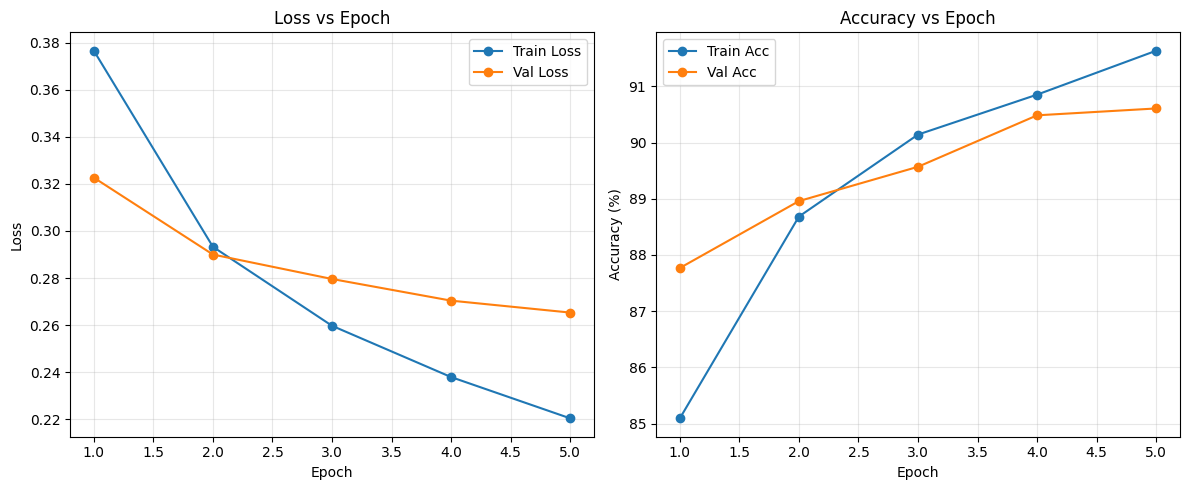

Saved training curves to: /content/Deepfake-Detection-KYC/outputs/plots/training_curves.png


In [25]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a * 100 for a in history["train_accuracy"]], marker="o", label="Train Acc")
axes[1].plot(epochs_range, [a * 100 for a in history["val_accuracy"]], marker="o", label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy vs Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

curves_path = PLOTS_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()

print("Saved training curves to:", curves_path)


## 13. Load the best checkpoint

In [26]:
# Reload a fresh MobileNetV2 skeleton and load the best saved weights, so
# evaluation below is guaranteed to use the best checkpoint rather than
# whatever the model's in-memory state happens to be after the last epoch.
eval_model = mobilenet_v2(weights=None)
num_features = eval_model.classifier[1].in_features
eval_model.classifier[1] = nn.Linear(num_features, 2)

eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
eval_model = eval_model.to(device)
eval_model.eval()

print("Loaded best checkpoint from:", BEST_MODEL_PATH)


Loaded best checkpoint from: /content/Deepfake-Detection-KYC/outputs/models/mobilenetv2_baseline_best.pth


## 14. Test evaluation (complete test split)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

test_loss, _ = evaluate(eval_model, test_loader, criterion, device)

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = eval_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)
test_precision = precision_score(all_labels, all_predictions, zero_division=0)
test_recall = recall_score(all_labels, all_predictions, zero_division=0)
test_f1 = f1_score(all_labels, all_predictions, zero_division=0)
test_roc_auc = roc_auc_score(all_labels, all_probabilities)

print("===================================")
print("MOBILENETV2 BASELINE TEST RESULTS")
print("===================================")
print(f"Test samples evaluated: {len(all_labels)} (expected {len(test_dataset)})")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%  (FAKE = positive class)")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1 Score  : {test_f1 * 100:.2f}%")
print(f"ROC-AUC   : {test_roc_auc:.4f}")


MOBILENETV2 BASELINE TEST RESULTS
Test samples evaluated: 6436 (expected 6436)
Test Loss : 0.2556
Accuracy  : 90.24%
Precision : 91.20%  (FAKE = positive class)
Recall    : 97.75%
F1 Score  : 94.36%
ROC-AUC   : 0.9020


## 15. Confusion matrix

Labels: `0 = REAL`, `1 = FAKE` (matches `FaceDataset`'s class mapping). Rows are
true labels, columns are predicted labels.

Confusion Matrix (rows=true, cols=predicted):
[[ 552  507]
 [ 121 5256]]


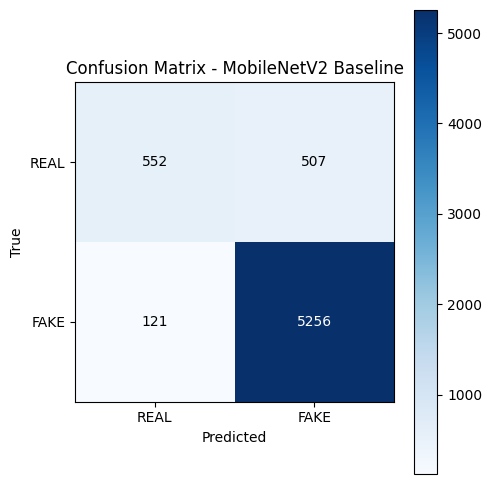

Saved confusion matrix plot to: /content/Deepfake-Detection-KYC/outputs/plots/confusion_matrix.png


In [28]:
cm = confusion_matrix(all_labels, all_predictions)
class_names = ["REAL", "FAKE"]

print("Confusion Matrix (rows=true, cols=predicted):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - MobileNetV2 Baseline")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()

cm_path = PLOTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print("Saved confusion matrix plot to:", cm_path)


## 16. Classification report

In [29]:
report_text = classification_report(
    all_labels, all_predictions, target_names=class_names, zero_division=0
)
print(report_text)

report_dict = classification_report(
    all_labels, all_predictions, target_names=class_names,
    zero_division=0, output_dict=True,
)


              precision    recall  f1-score   support

        REAL       0.82      0.52      0.64      1059
        FAKE       0.91      0.98      0.94      5377

    accuracy                           0.90      6436
   macro avg       0.87      0.75      0.79      6436
weighted avg       0.90      0.90      0.89      6436



## 17. Final results summary

In [30]:
summary = {
    "dataset_counts": DATASET_COUNTS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_val_accuracy": best_val_accuracy,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_roc_auc": test_roc_auc,
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "checkpoint_path": str(BEST_MODEL_PATH),
}

summary_path = METRICS_DIR / "test_results.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("===================================")
print("FINAL RESULTS SUMMARY")
print("===================================")
print(f"Best Val Accuracy : {best_val_accuracy * 100:.2f}%")
print(f"Test Accuracy      : {test_accuracy * 100:.2f}%")
print(f"Test Precision(FAKE): {test_precision * 100:.2f}%")
print(f"Test Recall(FAKE)  : {test_recall * 100:.2f}%")
print(f"Test F1(FAKE)      : {test_f1 * 100:.2f}%")
print(f"Test ROC-AUC       : {test_roc_auc:.4f}")
print()
print("Checkpoint:", BEST_MODEL_PATH)
print("Training history:", METRICS_DIR / "training_history.json")
print("Test results JSON:", summary_path)
print("Plots directory:", PLOTS_DIR)


FINAL RESULTS SUMMARY
Best Val Accuracy : 90.61%
Test Accuracy      : 90.24%
Test Precision(FAKE): 91.20%
Test Recall(FAKE)  : 97.75%
Test F1(FAKE)      : 94.36%
Test ROC-AUC       : 0.9020

Checkpoint: /content/Deepfake-Detection-KYC/outputs/models/mobilenetv2_baseline_best.pth
Training history: /content/Deepfake-Detection-KYC/outputs/metrics/training_history.json
Test results JSON: /content/Deepfake-Detection-KYC/outputs/metrics/test_results.json
Plots directory: /content/Deepfake-Detection-KYC/outputs/plots


## 18. Download the checkpoint

`/content` is ephemeral and disconnecting the Colab runtime will delete everything
saved above. Run this cell **manually** whenever you want to download the best
checkpoint to your local machine (it is *not* triggered automatically).

In [31]:
# Run this cell manually to download the checkpoint - it does not run automatically.
if IN_COLAB:
    from google.colab import files
    if BEST_MODEL_PATH.exists():
        files.download(str(BEST_MODEL_PATH))
    else:
        print("Checkpoint not found at:", BEST_MODEL_PATH)
else:
    print("Not running in Colab - checkpoint is already available locally at:")
    print(BEST_MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>